# Fase 4a — Generación del dataset de preguntas (TRAIN)

Genera los pares pregunta-contexto de entrenamiento que se usarán para el *fine-tuning* del modelo de embeddings (Fase 5b), a partir de los macro-contextos de `dataset_train.json` (Fase 3a).

1. **Generación con Gemini** (`generar_preguntas_gemini_train`, `procesar_train`): para cada macro-contexto, `gemini-2.5-pro` genera 4 tipos de pregunta (Directa, Caso, Compleja, Concepto), cada una con su `cita_literal` de respaldo extraída textualmente del macro-contexto, variando aleatoriamente el rol clínico que formula la pregunta (residente, especialista, enfermero, farmacéutico, médico de familia).
2. **Filtrado de alucinaciones** (`auditar_train`): descarta las preguntas cuya cita no se pueda localizar de forma suficientemente fiel (similitud difusa con `thefuzz` ≥ 90%) en el macro-contexto original.
3. **Auditoría de granularidad** (`auditar_granularidad_train`): distribución por tipo de pregunta, longitud de preguntas/citas y control de integridad de campos.
4. **Expansión de contexto** (`expandir_dataset`): las citas, inicialmente muy breves (la frase mínima necesaria), se amplían hasta una longitud objetivo variable (10% cortas, 60% en rango ideal 400–700 caracteres, 30% hasta 700–1000), añadiendo contexto a izquierda/derecha y respetando los límites de frase/párrafo, para que se asemejen al tamaño real de los chunks de producción.
5. **Re-auditoría** sobre el dataset ya expandido (`preguntas_train_expandido.json`).
6. **Comparación final** (`analizar_distribucion_y_atipicos`): contrasta, mediante percentiles y gráficos (boxplot y curva de densidad), la longitud de los contextos de TRAIN expandidos frente a los chunks reales generados por las cuatro estrategias de la Fase 3b.

> **Nota de seguridad:** la clave de la API de Gemini se ha sustituido por un marcador de posición (`TU_GOOGLE_API_KEY_AQUI`); debe configurarse como variable de entorno o sustituirse por una clave propia antes de ejecutar el notebook.

In [1]:
pip install thefuzz python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 19.7 MB/s eta 0:00:00


In [2]:
pip install --upgrade google-generativeai

In [3]:
import json
import random
import time
import google.generativeai as genai

# ==========================================
# CONFIGURACIÓN DE GEMINI
# ==========================================
API_KEY = "TU_GOOGLE_API_KEY_AQUI" # Pon tu API Key
genai.configure(api_key=API_KEY)

MODELO_ELEGIDO = 'gemini-2.5-pro'

ROLES = [
    "un médico residente de primer año que formula preguntas para entender conceptos clínicos",
    "un especialista adjunto repasando un protocolo específico",
    "un enfermero de urgencias que recuerda parcialmente un término médico y formula la pregunta de forma aproximada",
    "un farmacéutico hospitalario revisando interacciones",
    "un médico de familia en consulta con un paciente"
]

INSTRUCCIONES_SISTEMA = """
    Eres un experto creando datasets de entrenamiento para modelos de IA médica (Embeddings/RAG).
    Vas a leer un texto médico y generar 4 tipos de preguntas asumiendo varios roles.

    REGLA ANTI-BUCLE: Sé creativo con la formulación. PROHIBIDO empezar todas las preguntas igual.
    La pregunta debe estar PARAFRASEADA respecto al texto.

    TAREA: Genera un JSON estricto con 4 preguntas que SIEMPRE tengan respuesta en el texto:
    1. "Directa": Factual y sencilla (Dosis, síntomas, etc.).
    2. "Caso": Aplicación a un paciente ficticio.
    3. "Compleja": Requiere unir dos conceptos del texto.
    4. "Concepto": Pregunta sobre el porqué, la definición o el mecanismo de acción de algo mencionado.

    REGLA DE CITA:
    Para cada pregunta, extrae una cita_literal exacta del texto que contenga la respuesta mínima necesaria.
    No resumas.
    No inventes.
    No añadas texto fuera del fragmento copiado literalmente.

    Devuelve ÚNICAMENTE este JSON:
    [
      {{
        "tipo": "Directa",
        "pregunta": "...",
        "cita_literal": "..."
      }},
      {{
        "tipo": "Caso",
        "pregunta": "...",
        "cita_literal": "..."
      }},
      {{
        "tipo": "Compleja",
        "pregunta": "...",
        "cita_literal": "..."
      }},
      {{
        "tipo": "Concepto",
        "pregunta": "...",
        "cita_literal": "..."
      }}
    ]
    """

# Inicializamos el modelo con las instrucciones del sistema
model = genai.GenerativeModel(
    model_name=MODELO_ELEGIDO,
    system_instruction=INSTRUCCIONES_SISTEMA
)

def generar_preguntas_gemini_train(macro_contexto_texto, reintentos=3):
    """
    Genera con Gemini 4 preguntas (Directa, Caso, Compleja, Concepto) sobre
    un macro-contexto, cada una con su cita literal de respaldo, asumiendo
    aleatoriamente uno de los roles clínicos definidos en ROLES. Reintenta
    ante fallos de parseo JSON, bloqueos de seguridad o límite de tasa (429)
    hasta agotar `reintentos`.
    """
    rol = random.choice(ROLES)

    prompt = f"Asumiendo el rol de: {rol}, genera las 4 preguntas para el siguiente texto:\n\n{macro_contexto_texto}"

    configuracion = genai.GenerationConfig(
        response_mime_type="application/json",
        temperature=0.4
    )

    for intento in range(reintentos):
        try:
            respuesta = model.generate_content(prompt, generation_config=configuracion)

            if not respuesta.parts:
                 print(f"  [!] Respuesta bloqueada por filtros de seguridad de la API (Intento {intento+1}).")
                 time.sleep(2)
                 continue

            texto_limpio = respuesta.text.strip()

            if texto_limpio.startswith("```json"):
                texto_limpio = texto_limpio[7:-3]
            elif texto_limpio.startswith("```"):
                texto_limpio = texto_limpio[3:-3]

            return json.loads(texto_limpio.strip())

        except json.JSONDecodeError:
            print(f"  [!] Fallo al parsear JSON (Intento {intento+1}). Reintentando...")
            time.sleep(2)
        except Exception as e:
            if "429" in str(e):
                print(f"  [!] Límite de API (429). Esperando 10s... (Intento {intento+1})")
                time.sleep(10)
            else:
                print(f"  [!] Error de API: {e} (Intento {intento+1})")
                time.sleep(2)

    raise Exception("Se agotaron los reintentos para este bloque.")

def procesar_train(ruta_train='dataset_train.json', ruta_salida='preguntas_train.json'):
    """
    Recorre todos los macro-contextos de entrenamiento, genera sus preguntas
    con generar_preguntas_gemini_train, añade a cada una los metadatos de
    origen (macro_id, documento) y guarda el resultado conjunto en un JSON.
    """
    print(f"INICIANDO GENERACIÓN DE DATASET DE ENTRENAMIENTO (TRAIN)...")

    with open(ruta_train, 'r', encoding='utf-8') as f:
        datos_train = json.load(f)

    resultados_finales = []
    total = len(datos_train)

    for i, bloque in enumerate(datos_train, 1):
        print(f"[{i}/{total}] Procesando bloque de: {bloque.get('source', 'Desconocido')[:30]}...")

        try:
            preguntas_generadas = generar_preguntas_gemini_train(bloque["text"])

            for p in preguntas_generadas:
                cita = p.get("cita_literal", "")
                # if len(cita) > 1050:
                #     print(f"    [Aviso] Cita un poco larga ({len(cita)} chars) en tipo '{p['tipo']}'")
                # if len(cita) < 100:
                #     print(f"    [Aviso] Cita demasiado corta ({len(cita)} chars) en tipo '{p['tipo']}'")

                # Inyectamos metadatos clave para el entrenamiento
                p["macro_id_origen"] = bloque["macro_id"]
                p["source"] = bloque.get("source", "Desconocido")
                resultados_finales.append(p)

            time.sleep(2)

        except Exception as e:
            print(f" [ERROR CRÍTICO] Saltando bloque {i}: {e}")
            continue

    with open(ruta_salida, 'w', encoding='utf-8') as f:
        json.dump(resultados_finales, f, ensure_ascii=False, indent=4)

    print(f"\n¡Generación de Train completada! Se han generado {len(resultados_finales)} pares de entrenamiento.")
    print(f"Guardado en: {ruta_salida}")

if __name__ == "__main__":
    procesar_train()

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


INICIANDO GENERACIÓN DE DATASET DE ENTRENAMIENTO (TRAIN)...
[1/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[2/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[3/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[4/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[5/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[6/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[7/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[8/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[9/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[10/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[11/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[12/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[13/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[14/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[15/275] Procesando bloque de: 1181_Guí

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1570.42ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 961.73ms


[26/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[27/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[28/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[29/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[30/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[31/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[32/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[33/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[34/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[35/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[36/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[37/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[38/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[39/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[40/275] Procesando bloque de: 1181_Guía hospitalaria de tera...
[41/275] Procesando bloqu

ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1518.62ms


...

[255/275] Procesando bloque de: 13584_Protocolo de vigilancia ...
[256/275] Procesando bloque de: 13584_Protocolo de vigilancia ...
[257/275] Procesando bloque de: 13584_Protocolo de vigilancia ...
[258/275] Procesando bloque de: 13584_Protocolo de vigilancia ...
[259/275] Procesando bloque de: 13584_Protocolo de vigilancia ...
[260/275] Procesando bloque de: 13584_Protocolo de vigilancia ...
[261/275] Procesando bloque de: 16304_Protocolo para la admini...
[262/275] Procesando bloque de: 16304_Protocolo para la admini...
[263/275] Procesando bloque de: 16304_Protocolo para la admini...


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 937.48ms


[264/275] Procesando bloque de: 16304_Protocolo para la admini...
[265/275] Procesando bloque de: 16304_Protocolo para la admini...
[266/275] Procesando bloque de: 16304_Protocolo para la admini...
[267/275] Procesando bloque de: 16304_Protocolo para la admini...
[268/275] Procesando bloque de: 16304_Protocolo para la admini...


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-pro:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 810.27ms


[269/275] Procesando bloque de: 16304_Protocolo para la admini...
[270/275] Procesando bloque de: 16304_Protocolo para la admini...
[271/275] Procesando bloque de: 16304_Protocolo para la admini...
[272/275] Procesando bloque de: 11864_Procedimiento para el cu...
[273/275] Procesando bloque de: 11864_Procedimiento para el cu...
[274/275] Procesando bloque de: 10604_Protocolo de uso de Nivo...
[275/275] Procesando bloque de: 10604_Protocolo de uso de Nivo...

¡Generación de Train completada! Se han generado 1100 pares de entrenamiento.
Guardado en: preguntas_train.json


In [20]:
import json
import re
import os
from thefuzz import fuzz

# ==========================================
# CONFIGURACIÓN DE ARCHIVOS
# ==========================================
ARCHIVO_PREGUNTAS_TRAIN = 'preguntas_train.json'
ARCHIVO_DATASET_TRAIN = 'dataset_train.json'
ARCHIVO_SALIDA_TRAIN = 'preguntas_train_final.json'

UMBRAL_FUZZY = 90  # % de similitud mínima

def procesar_cita_multisalto(cita_llm):
    """Divide las citas si Gemini usó separadores."""
    if cita_llm in ["NO APLICA", "NULL", ""]:
        return []
    fragmentos = re.split(r'\||\.\.\.|\[\.\.\.\]', cita_llm)
    return [f.strip().lower() for f in fragmentos if (len(f.strip()) > 40)]

def auditar_train():
    """
    Filtra las preguntas generadas para TRAIN descartando aquellas cuya
    cita_literal no se encuentra de forma suficientemente fiel (fuzzy
    matching >= UMBRAL_FUZZY) en el macro-contexto original, eliminando así
    alucinaciones del LLM, y guarda el dataset depurado.
    """
    print("="*70)
    print(" INICIANDO LIMPIEZA DE RUIDO PARA EL DATASET DE ENTRENAMIENTO ".center(70))
    print("="*70)

    if not os.path.exists(ARCHIVO_PREGUNTAS_TRAIN) or not os.path.exists(ARCHIVO_DATASET_TRAIN):
        print("[ERROR] Faltan los archivos de TRAIN.")
        return

    with open(ARCHIVO_PREGUNTAS_TRAIN, 'r', encoding='utf-8') as f:
        preguntas = json.load(f)
    with open(ARCHIVO_DATASET_TRAIN, 'r', encoding='utf-8') as f:
        dataset_train = json.load(f)

    # Diccionario rápido: {macro_id: texto_original}
    diccionario_macro_contextos = {bloque["macro_id"]: bloque["text"].lower() for bloque in dataset_train}

    preguntas_limpias = []
    alucinaciones = 0

    print(f"-> Analizando {len(preguntas)} pares de entrenamiento generados...\n")

    for p in preguntas:
        cita_original = p.get("cita_literal", "")
        macro_id = p.get("macro_id_origen", "")

        # Saltamos si por algún error Gemini coló una negativa
        if cita_original in ["NO APLICA", "NULL", ""]:
            continue

        # Eliminamos citas demasiado largas
        if len(cita_original) > 1000:
            alucinaciones += 1
            continue

        sub_citas = procesar_cita_multisalto(cita_original)
        if not sub_citas:
            alucinaciones += 1
            continue

        texto_base = diccionario_macro_contextos.get(macro_id, "")

        # Verificamos si la cita es fiel al texto original
        es_fiel = all(fuzz.partial_ratio(sub, texto_base) >= UMBRAL_FUZZY for sub in sub_citas)

        if es_fiel:
            preguntas_limpias.append(p)
        else:
            alucinaciones += 1

    # Guardamos el dataset final de entrenamiento
    with open(ARCHIVO_SALIDA_TRAIN, 'w', encoding='utf-8') as f:
        json.dump(preguntas_limpias, f, ensure_ascii=False, indent=4)

    print(f"Limpieza de TRAIN completada.")
    print(f"   - Preguntas originales: {len(preguntas)}")
    print(f"   - Descartadas por formato/alucinación: {alucinaciones}")
    print(f"   - DATASET DE ENTRENAMIENTO FINAL: {len(preguntas_limpias)} pares útiles.")
    print(f"   - Guardado en: '{ARCHIVO_SALIDA_TRAIN}'")
    print("="*70)

if __name__ == "__main__":
    auditar_train()

     INICIANDO LIMPIEZA DE RUIDO PARA EL DATASET DE ENTRENAMIENTO     
-> Analizando 1100 pares de entrenamiento generados...

Limpieza de TRAIN completada.
   - Preguntas originales: 1100
   - Descartadas por formato/alucinación: 85
   - DATASET DE ENTRENAMIENTO FINAL: 1015 pares útiles.
   - Guardado en: 'preguntas_train_final.json'


In [21]:
import json
import statistics
import random
from collections import Counter

# Cambiamos al archivo final de entrenamiento
ARCHIVO_PREGUNTAS = 'preguntas_train_final.json'

def calcular_metricas(lista_textos, etiqueta):
    """Calcula e imprime las métricas de longitud de una lista de textos."""
    longitudes = [len(t) for t in lista_textos if t] # Evitamos textos vacíos por seguridad

    if not longitudes:
        print(f" -> {etiqueta}: No hay datos suficientes.")
        return

    print(f" -> {etiqueta}:")
    print(f"      Media:   {statistics.mean(longitudes):.0f} caracteres")
    print(f"      Mediana: {statistics.median(longitudes):.0f} caracteres")
    print(f"      Máxima:  {max(longitudes)} caracteres")
    print(f"      Mínima:  {min(longitudes)} caracteres")

def auditar_granularidad_train():
    """
    Calcula y muestra estadísticas de granularidad del dataset de
    entrenamiento final: distribución por tipo de pregunta, longitud de
    preguntas y citas, control de integridad de campos y una muestra
    aleatoria.
    """
    print("="*80)
    print(" INICIANDO ANÁLISIS DE GRANULARIDAD DEL DATASET DE ENTRENAMIENTO ".center(80))
    print("="*80)

    try:
        with open(ARCHIVO_PREGUNTAS, 'r', encoding='utf-8') as f:
            preguntas = json.load(f)
    except FileNotFoundError:
        print(f"[X] Archivo no encontrado: {ARCHIVO_PREGUNTAS}")
        return

    if not preguntas:
        print("El dataset está vacío.")
        return

    # --- 1. MÉTRICAS DE DISTRIBUCIÓN ---
    print("\n[ 1. DISTRIBUCIÓN POR TIPO DE PREGUNTA ]")
    print("-" * 50)
    print(f" -> Total de pares validados (Pregunta/Cita): {len(preguntas)}")

    tipos = [p.get("tipo", "Desconocido") for p in preguntas]
    conteo_tipos = Counter(tipos)

    for t, count in conteo_tipos.items():
        print(f"      - {t}: {count} preguntas ({(count/len(preguntas))*100:.1f}%)")

    # --- 2. MÉTRICAS DE LONGITUD LÉXICA ---
    print("\n[ 2. GRANULARIDAD LÉXICA (Caracteres) ]")
    print("-" * 50)

    # Extraemos las listas de textos
    textos_preguntas = [p.get("pregunta", "") for p in preguntas]

    # Aquí no debería haber negativas, pero mantenemos el filtro por pura seguridad
    textos_citas = [p.get("cita_literal", "") for p in preguntas if p.get("cita_literal", "") not in ["NO APLICA", "NULL", ""]]

    calcular_metricas(textos_preguntas, "Longitud de las PREGUNTAS (Query para RAG)")
    print("")
    calcular_metricas(textos_citas, "Longitud de las CITAS LITERALES (Contexto Positivo para el Modelo)")

    # --- 3. CONTROL DE CALIDAD Y ESTRUCTURA ---
    print("\n[ 3. CONTROL DE CALIDAD Y ESTRUCTURA ]")
    print("-" * 50)

    # Eliminamos 'respuesta_ideal' de las claves a buscar
    claves_base = ["tipo", "pregunta", "cita_literal", "macro_id_origen", "source"]
    muestra_p = preguntas[0]
    claves_ok = all(k in muestra_p for k in claves_base)
    print(f" -> Integridad de claves base: {'OK (Listas para Fine-Tuning)' if claves_ok else 'ERROR: Faltan campos clave'}")

    # --- 4. MUESTRA VISUAL ---
    muestra = random.choice(preguntas)
    print("\n[ MUESTRA AL AZAR ]")
    print("-" * 50)
    print(f" -> Tipo:      {muestra.get('tipo')}")
    print(f" -> Documento: {muestra.get('source')}")
    print(f" -> Pregunta:  \"{muestra.get('pregunta')}\"")

    cita_corta = muestra.get('cita_literal', '')
    if len(cita_corta) > 100: cita_corta = cita_corta[:100] + "..."
    print(f" -> Cita:      \"{cita_corta}\"")
    print("="*80)

if __name__ == "__main__":
    auditar_granularidad_train()

        INICIANDO ANÁLISIS DE GRANULARIDAD DEL DATASET DE ENTRENAMIENTO         

[ 1. DISTRIBUCIÓN POR TIPO DE PREGUNTA ]
--------------------------------------------------
 -> Total de pares validados (Pregunta/Cita): 1015
      - Directa: 241 preguntas (23.7%)
      - Caso: 252 preguntas (24.8%)
      - Compleja: 255 preguntas (25.1%)
      - Concepto: 267 preguntas (26.3%)

[ 2. GRANULARIDAD LÉXICA (Caracteres) ]
--------------------------------------------------
 -> Longitud de las PREGUNTAS (Query para RAG):
      Media:   160 caracteres
      Mediana: 158 caracteres
      Máxima:  338 caracteres
      Mínima:  66 caracteres

 -> Longitud de las CITAS LITERALES (Contexto Positivo para el Modelo):
      Media:   188 caracteres
      Mediana: 170 caracteres
      Máxima:  660 caracteres
      Mínima:  41 caracteres

[ 3. CONTROL DE CALIDAD Y ESTRUCTURA ]
--------------------------------------------------
 -> Integridad de claves base: OK (Listas para Fine-Tuning)

[ MUESTRA AL AZAR

In [22]:
import json
import random
import re

ARCHIVO_PREGUNTAS = 'preguntas_train_final.json'  # El que ya pasaste por tu script de thefuzz
ARCHIVO_MACRO_DOCS = 'dataset_train.json'
ARCHIVO_SALIDA = 'preguntas_train_expandido.json'

def cargar_json(ruta):
    """
    Carga y devuelve el contenido de un fichero JSON.
    """
    with open(ruta, 'r', encoding='utf-8') as f:
        return json.load(f)

def procesar_bordes_multisalto(cita_llm):
    """Extrae el primer y último fragmento usando tu misma lógica Regex"""
    fragmentos = re.split(r'\.\.\.|\[\.\.\.\]', cita_llm)
    # Filtramos fragmentos muy pequeños que puedan ser ruido
    fragmentos_validos = [f.strip() for f in fragmentos if len(f.strip()) > 10]

    if not fragmentos_validos:
        return None, None

    # Devolvemos el inicio absoluto y el fin absoluto
    return fragmentos_validos[0], fragmentos_validos[-1]

def expandir_dataset():
    """
    Expande cada cita literal (originalmente acotada a la mínima frase
    necesaria) hasta una longitud objetivo variable (perfil 10% corta /
    60% ideal 400-700 / 30% máxima 700-1000 caracteres), añadiendo contexto
    a izquierda y/o derecha respetando los límites de frase/párrafo, para
    que el contexto positivo de entrenamiento se parezca en tamaño a los
    chunks reales que usará el sistema RAG.
    """
    print("="*70)
    print(" INICIANDO EXPANSIÓN SEMÁNTICA DE CONTEXTO ".center(70))
    print("="*70)

    preguntas = cargar_json(ARCHIVO_PREGUNTAS)
    macro_docs_raw = cargar_json(ARCHIVO_MACRO_DOCS)

    # Diccionario rápido
    macro_docs = {doc['macro_id']: doc['text'] for doc in macro_docs_raw}

    resultados = []
    fallos_busqueda = 0

    for p in preguntas:
        cita = p.get('cita_literal', '')
        macro_id = p.get('macro_id_origen', '')
        texto_completo = macro_docs.get(macro_id, '')

        if not cita or not texto_completo:
            continue

        # 1. RESOLUCIÓN DE MULTI-SALTO CON TU REGEX
        inicio_cita, fin_cita = procesar_bordes_multisalto(cita)

        if not inicio_cita or not fin_cita:
            fallos_busqueda += 1
            resultados.append(p)
            continue

        idx_inicio = texto_completo.find(inicio_cita)

        # Para el fin, buscamos a partir de donde encontramos el inicio
        temp_idx_fin = texto_completo.find(fin_cita, max(0, idx_inicio))

        if idx_inicio == -1 or temp_idx_fin == -1:
            # Fallback: dejamos la cita tal cual si no la encontramos exacta
            resultados.append(p)
            fallos_busqueda += 1
            continue

        idx_fin = temp_idx_fin + len(fin_cita)
        longitud_actual = idx_fin - idx_inicio

        # 2. SELECCIÓN DE PERFIL DE DISTRIBUCIÓN
        probabilidad = random.random()
        if probabilidad < 0.10:
            target_len = longitud_actual # 10% se quedan cortas
        elif probabilidad < 0.70:
            target_len = random.randint(400, 700) # 60% tamaño ideal
        else:
            target_len = random.randint(700, 1000) # 30% tamaño máximo (overlap)

        chars_a_añadir = max(0, target_len - longitud_actual)

        # 3. ALEATORIEDAD DIRECCIONAL
        direccion = random.choice([0, 1, 2])
        add_izq = chars_a_añadir if direccion == 0 else (chars_a_añadir // 2 if direccion == 2 else 0)
        add_der = chars_a_añadir if direccion == 1 else (chars_a_añadir // 2 if direccion == 2 else 0)

        nuevo_inicio = max(0, idx_inicio - add_izq)
        nuevo_fin = min(len(texto_completo), idx_fin + add_der)

        # 4. EXPANSIÓN HASTA FRONTERA SEMÁNTICA (Puntos) SIN SALTAR DE PÁRRAFO (\n\n)
        # Hacia la izquierda
        while nuevo_inicio > 0 and texto_completo[nuevo_inicio] not in ['.', '\n']:
            nuevo_inicio -= 1
        # Si chocamos con un salto de línea, nos detenemos ahí (protección semántica)
        if nuevo_inicio > 0 and texto_completo[nuevo_inicio] == '.':
            nuevo_inicio += 1

        # Hacia la derecha
        while nuevo_fin < len(texto_completo) and texto_completo[nuevo_fin] not in ['.', '\n']:
            nuevo_fin += 1
        if nuevo_fin < len(texto_completo) and texto_completo[nuevo_fin] == '.':
            nuevo_fin += 1

        # 5. GUARDAR RESULTADO
        cita_final = texto_completo[nuevo_inicio:nuevo_fin].strip()

        # Sobrescribimos con la nueva cita expandida y controlada
        p['cita_literal'] = cita_final
        resultados.append(p)

    with open(ARCHIVO_SALIDA, 'w', encoding='utf-8') as f:
        json.dump(resultados, f, ensure_ascii=False, indent=4)

    print(f"¡Expansión completada con éxito!")
    print(f" -> Citas expandidas correctamente: {len(resultados) - fallos_busqueda}")
    print(f" -> Citas mantenidas originales (fallback por no encontrar substring exacto): {fallos_busqueda}")
    print(f" -> Guardado en: {ARCHIVO_SALIDA}")
    print("="*70)

if __name__ == "__main__":
    expandir_dataset()

              INICIANDO EXPANSIÓN SEMÁNTICA DE CONTEXTO               
¡Expansión completada con éxito!
 -> Citas expandidas correctamente: 980
 -> Citas mantenidas originales (fallback por no encontrar substring exacto): 35
 -> Guardado en: preguntas_train_expandido.json


In [23]:
import json
import statistics
import random
from collections import Counter

# Cambiamos al archivo final de entrenamiento
ARCHIVO_PREGUNTAS = 'preguntas_train_expandido.json'

def calcular_metricas(lista_textos, etiqueta):
    """Calcula e imprime las métricas de longitud de una lista de textos."""
    longitudes = [len(t) for t in lista_textos if t] # Evitamos textos vacíos por seguridad

    if not longitudes:
        print(f" -> {etiqueta}: No hay datos suficientes.")
        return

    print(f" -> {etiqueta}:")
    print(f"      Media:   {statistics.mean(longitudes):.0f} caracteres")
    print(f"      Mediana: {statistics.median(longitudes):.0f} caracteres")
    print(f"      Máxima:  {max(longitudes)} caracteres")
    print(f"      Mínima:  {min(longitudes)} caracteres")

def auditar_granularidad_train():
    """
    Misma auditoría de granularidad que en la celda anterior, aplicada
    ahora sobre el dataset ya expandido por expandir_dataset (citas con
    contexto ampliado en lugar de la frase mínima original).
    """
    print("="*80)
    print(" INICIANDO ANÁLISIS DE GRANULARIDAD DEL DATASET DE ENTRENAMIENTO ".center(80))
    print("="*80)

    try:
        with open(ARCHIVO_PREGUNTAS, 'r', encoding='utf-8') as f:
            preguntas = json.load(f)
    except FileNotFoundError:
        print(f"[X] Archivo no encontrado: {ARCHIVO_PREGUNTAS}")
        return

    if not preguntas:
        print("El dataset está vacío.")
        return

    # --- 1. MÉTRICAS DE DISTRIBUCIÓN ---
    print("\n[ 1. DISTRIBUCIÓN POR TIPO DE PREGUNTA ]")
    print("-" * 50)
    print(f" -> Total de pares validados (Pregunta/Cita): {len(preguntas)}")

    tipos = [p.get("tipo", "Desconocido") for p in preguntas]
    conteo_tipos = Counter(tipos)

    for t, count in conteo_tipos.items():
        print(f"      - {t}: {count} preguntas ({(count/len(preguntas))*100:.1f}%)")

    # --- 2. MÉTRICAS DE LONGITUD LÉXICA ---
    print("\n[ 2. GRANULARIDAD LÉXICA (Caracteres) ]")
    print("-" * 50)

    # Extraemos las listas de textos
    textos_preguntas = [p.get("pregunta", "") for p in preguntas]

    # Aquí no debería haber negativas, pero mantenemos el filtro por pura seguridad
    textos_citas = [p.get("cita_literal", "") for p in preguntas if p.get("cita_literal", "") not in ["NO APLICA", "NULL", ""]]

    calcular_metricas(textos_preguntas, "Longitud de las PREGUNTAS (Query para RAG)")
    print("")
    calcular_metricas(textos_citas, "Longitud de las CITAS LITERALES (Contexto Positivo para el Modelo)")

    # --- 3. CONTROL DE CALIDAD Y ESTRUCTURA ---
    print("\n[ 3. CONTROL DE CALIDAD Y ESTRUCTURA ]")
    print("-" * 50)

    # Eliminamos 'respuesta_ideal' de las claves a buscar
    claves_base = ["tipo", "pregunta", "cita_literal", "macro_id_origen", "source"]
    muestra_p = preguntas[0]
    claves_ok = all(k in muestra_p for k in claves_base)
    print(f" -> Integridad de claves base: {'OK (Listas para Fine-Tuning)' if claves_ok else 'ERROR: Faltan campos clave'}")

    # --- 4. MUESTRA VISUAL ---
    muestra = random.choice(preguntas)
    print("\n[ MUESTRA AL AZAR ]")
    print("-" * 50)
    print(f" -> Tipo:      {muestra.get('tipo')}")
    print(f" -> Documento: {muestra.get('source')}")
    print(f" -> Pregunta:  \"{muestra.get('pregunta')}\"")

    cita_corta = muestra.get('cita_literal', '')
    if len(cita_corta) > 100: cita_corta = cita_corta[:100] + "..."
    print(f" -> Cita:      \"{cita_corta}\"")
    print("="*80)

if __name__ == "__main__":
    auditar_granularidad_train()

        INICIANDO ANÁLISIS DE GRANULARIDAD DEL DATASET DE ENTRENAMIENTO         

[ 1. DISTRIBUCIÓN POR TIPO DE PREGUNTA ]
--------------------------------------------------
 -> Total de pares validados (Pregunta/Cita): 1015
      - Directa: 241 preguntas (23.7%)
      - Caso: 252 preguntas (24.8%)
      - Compleja: 255 preguntas (25.1%)
      - Concepto: 267 preguntas (26.3%)

[ 2. GRANULARIDAD LÉXICA (Caracteres) ]
--------------------------------------------------
 -> Longitud de las PREGUNTAS (Query para RAG):
      Media:   160 caracteres
      Mediana: 158 caracteres
      Máxima:  338 caracteres
      Mínima:  66 caracteres

 -> Longitud de las CITAS LITERALES (Contexto Positivo para el Modelo):
      Media:   670 caracteres
      Mediana: 682 caracteres
      Máxima:  1574 caracteres
      Mínima:  59 caracteres

[ 3. CONTROL DE CALIDAD Y ESTRUCTURA ]
--------------------------------------------------
 -> Integridad de claves base: OK (Listas para Fine-Tuning)

[ MUESTRA AL AZA


 ANÁLISIS PROFUNDO DE DISTRIBUCIÓN Y PERCENTILES

ESTRATEGIA A (FIXED)
--------------------------------------------------
 -> Mínimo absoluto:                  31 caracteres
 -> Percentil  1% (Atípicos bajos):   74 caracteres
 -> Percentil  5% (Ruido bajo):       227 caracteres
 -> Mediana   50% (Centro real):      784 caracteres
 -> Percentil 95% (Textos largos):    989 caracteres
 -> Percentil 99% (Atípicos altos):   998 caracteres
 -> Máximo absoluto:                  999 caracteres

ESTRATEGIA B (MARKDOWN)
--------------------------------------------------
 -> Mínimo absoluto:                  44 caracteres
 -> Percentil  1% (Atípicos bajos):   55 caracteres
 -> Percentil  5% (Ruido bajo):       101 caracteres
 -> Mediana   50% (Centro real):      582 caracteres
 -> Percentil 95% (Textos largos):    1036 caracteres
 -> Percentil 99% (Atípicos altos):   1082 caracteres
 -> Máximo absoluto:                  1181 caracteres

ESTRATEGIA C (SEMÁNTICA)
----------------------------------

/tmp/ipykernel_735/1503446496.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Longitud", y="Fuente", data=df, showfliers=True, palette="Set2")


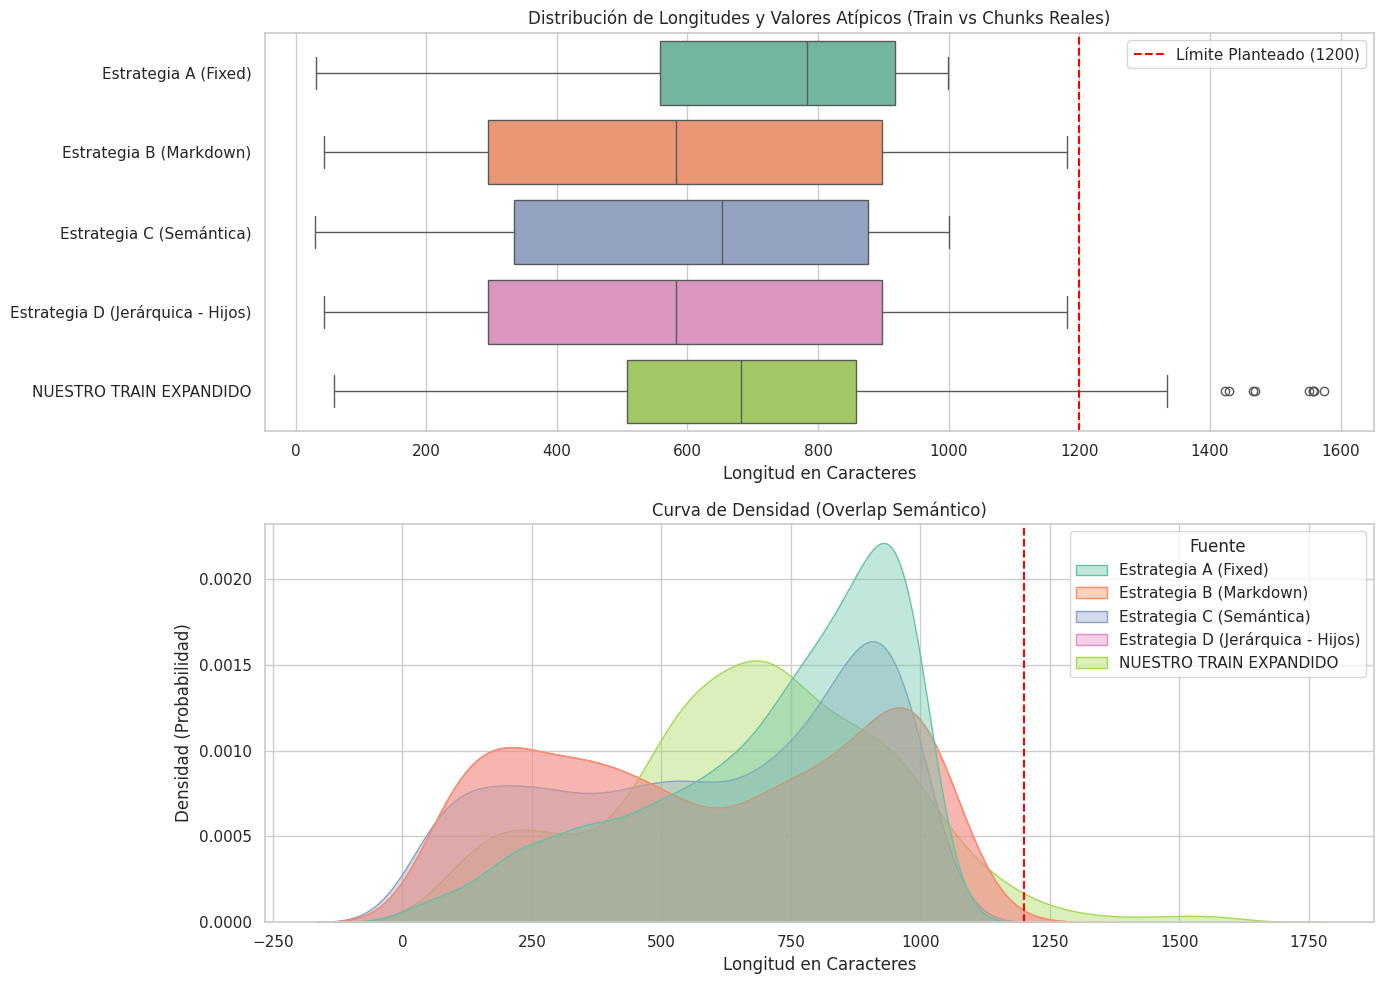

In [24]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURACIÓN DE ARCHIVOS A COMPARAR
# ==========================================
ARCHIVOS = {
    "Estrategia A (Fixed)": 'chunks_estrategia_A_fixed.json',
    "Estrategia B (Markdown)": 'chunks_estrategia_B_markdown.json',
    "Estrategia C (Semántica)": 'chunks_estrategia_C_semantica.json',
    "Estrategia D (Jerárquica - Hijos)": 'chunks_estrategia_D_jerarquico.json',
    "NUESTRO TRAIN EXPANDIDO": 'preguntas_train_expandido.json' # ¡Añadimos nuestro dataset!
}

def analizar_distribucion_y_atipicos():
    """
    Compara la distribución de longitudes de las citas expandidas de TRAIN
    frente a los chunks reales de las cuatro estrategias de la Fase 3b
    (percentiles, mínimo/máximo) y genera un boxplot y una curva de
    densidad para visualizar si el tamaño del contexto de entrenamiento es
    compatible con el de los chunks que se usarán en producción.
    """
    print("\n" + "="*75)
    print(" ANÁLISIS PROFUNDO DE DISTRIBUCIÓN Y PERCENTILES")
    print("="*75)

    datos_grafico = []

    for nombre, archivo in ARCHIVOS.items():
        try:
            with open(archivo, 'r', encoding='utf-8') as f:
                datos = json.load(f)
        except FileNotFoundError:
            print(f"[!] No se encontró el archivo '{archivo}'. Saltando...")
            continue

        longitudes = []

        # Lógica de extracción dependiendo de la estructura del archivo
        if nombre == "NUESTRO TRAIN EXPANDIDO":
            longitudes = [len(p.get("cita_literal", "")) for p in datos]
        elif "Jerárquica" in nombre:
            longitudes = [len(c["text"]) for c in datos if c.get("metadata", {}).get("doc_type") == "hijo"]
        else:
            longitudes = [len(c["text"]) for c in datos]

        if not longitudes:
            continue

        # Recopilar datos para el gráfico
        for l in longitudes:
            datos_grafico.append({"Fuente": nombre, "Longitud": l})

        # Calcular Percentiles clave
        p1 = np.percentile(longitudes, 1)   # El 1% son más pequeños que esto
        p5 = np.percentile(longitudes, 5)   # El 5% son más pequeños que esto
        p95 = np.percentile(longitudes, 95) # El 5% son más GRANDES que esto
        p99 = np.percentile(longitudes, 99) # El 1% son más GRANDES que esto
        maximo = np.max(longitudes)

        print(f"\n{nombre.upper()}")
        print("-" * 50)
        print(f" -> Mínimo absoluto:                  {np.min(longitudes):.0f} caracteres")
        print(f" -> Percentil  1% (Atípicos bajos):   {p1:.0f} caracteres")
        print(f" -> Percentil  5% (Ruido bajo):       {p5:.0f} caracteres")
        print(f" -> Mediana   50% (Centro real):      {np.median(longitudes):.0f} caracteres")
        print(f" -> Percentil 95% (Textos largos):    {p95:.0f} caracteres")
        print(f" -> Percentil 99% (Atípicos altos):   {p99:.0f} caracteres")
        print(f" -> Máximo absoluto:                  {maximo:.0f} caracteres")

    # --- GENERAR GRÁFICOS ---
    if not datos_grafico:
        print("\nNo hay datos para generar gráficas.")
        return

    df = pd.DataFrame(datos_grafico)

    # Configuración visual
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 10))

    # 1. Boxplot (Diagrama de caja para ver atípicos y guillotina)
    plt.subplot(2, 1, 1)
    sns.boxplot(x="Longitud", y="Fuente", data=df, showfliers=True, palette="Set2")

    # Línea vertical roja para marcar tu límite hipotético de 1200
    plt.axvline(x=1200, color='red', linestyle='--', label='Límite Planteado (1200)')
    plt.legend()

    plt.title("Distribución de Longitudes y Valores Atípicos (Train vs Chunks Reales)")
    plt.xlabel("Longitud en Caracteres")
    plt.ylabel("")

    # 2. Histograma superpuesto (Densidad)
    plt.subplot(2, 1, 2)
    sns.kdeplot(data=df, x="Longitud", hue="Fuente", fill=True, common_norm=False, alpha=0.4, palette="Set2")

    # Línea vertical roja en la curva de densidad
    plt.axvline(x=1200, color='red', linestyle='--')

    plt.title("Curva de Densidad (Overlap Semántico)")
    plt.xlabel("Longitud en Caracteres")
    plt.ylabel("Densidad (Probabilidad)")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analizar_distribucion_y_atipicos()